# Linear regression with SGD (`SGDRegressor`)

`LinearRegression` solves for the weights directly (normal equation / least squares). `SGDRegressor`
gets there iteratively with stochastic gradient descent, updating the weights one sample at a time. That
scales to datasets too big for memory and supports regularisation and online learning, but it has a lot
of knobs, and with the wrong settings it doesn't converge at all.

This notebook goes through making it work on California housing:

1. what happens with defaults
2. feature scaling
3. watching the loss epoch by epoch to pick a learning rate
4. validation curves for `eta0`
5. learning rate schedules, early stopping, averaging

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, ShuffleSplit, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(306)
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)

Three-way split: test (held out), and the rest split again into train and dev. Dev is used to compare
settings without touching test.

In [2]:
features, labels = fetch_california_housing(as_frame=True, return_X_y=True)

com_train_features, test_features, com_train_labels, test_labels = train_test_split(
    features, labels, random_state=42)
train_features, dev_features, train_labels, dev_labels = train_test_split(
    com_train_features, com_train_labels, random_state=42)

print("train:", len(train_features), " dev:", len(dev_features), " test:", len(test_features))

train: 11610  dev: 3870  test: 5160


In [3]:
def report(model, name=""):
    tr = mean_absolute_error(train_labels, model.predict(train_features))
    dv = mean_absolute_error(dev_labels, model.predict(dev_features))
    print(f"{name:30s} train MAE: {tr:.4g}   dev MAE: {dv:.4g}")

For reference, the closed-form solution:

In [4]:
report(Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())]).fit(train_features, train_labels),
       "LinearRegression")

LinearRegression               train MAE: 0.53   dev MAE: 0.5292


## 1. Defaults, no scaling

In [5]:
sgd = SGDRegressor(random_state=42).fit(train_features, train_labels)
report(sgd, "SGD, raw features")

SGD, raw features              train MAE: 3.279e+14   dev MAE: 3.311e+14


An error of around 10^14 (the target is between 0 and 5). The weights blew up. Population goes up to
35,000 while other features are around 1-10, so the gradient for some weights is thousands of times bigger
than for others, and the default step size overshoots more on every update.

## 2. Add scaling

In [6]:
sgd_pipe = Pipeline([("scale", StandardScaler()), ("sgd", SGDRegressor(random_state=42))])
sgd_pipe.fit(train_features, train_labels)
report(sgd_pipe, "SGD, scaled")

SGD, scaled                    train MAE: 0.7264   dev MAE: 1.013


Now it trains, but it's still worse than `LinearRegression` (around 0.53). Something about the
optimisation isn't right.

## 3. Watching the loss epoch by epoch

`partial_fit` does one pass (epoch) over the data per call, so the training loss can be recorded after
each one. `partial_fit` isn't available on a pipeline, so the features are scaled first.

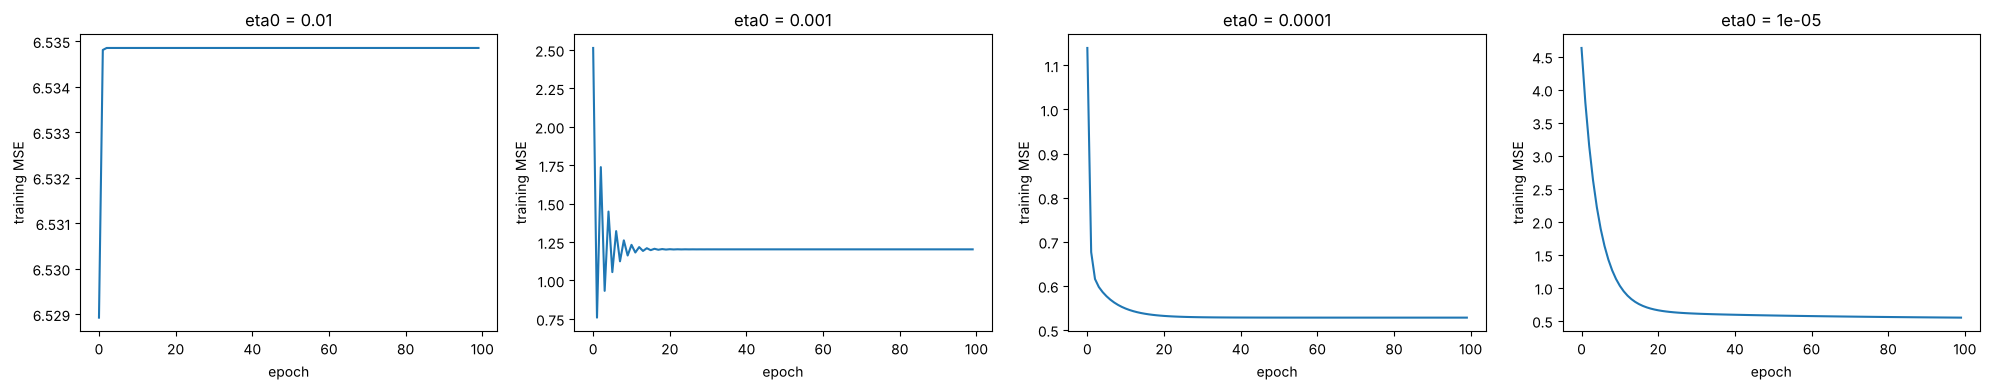

In [7]:
scaler = StandardScaler().fit(train_features)
X_tr = scaler.transform(train_features)

def loss_curve(eta0, epochs=100, schedule="constant"):
    model = SGDRegressor(eta0=eta0, learning_rate=schedule, random_state=42)
    losses = []
    for _ in range(epochs):
        model.partial_fit(X_tr, train_labels)
        losses.append(mean_squared_error(train_labels, model.predict(X_tr)))
    return losses

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, eta0 in zip(axes, [1e-2, 1e-3, 1e-4, 1e-5]):
    ax.plot(loss_curve(eta0))
    ax.set_title(f"eta0 = {eta0}")
    ax.set_xlabel("epoch"); ax.set_ylabel("training MSE")
plt.tight_layout()
plt.show()

* **eta0 = 0.01**: stuck at a training MSE of about 6.5, far worse than just predicting the mean.
  The steps are so big that the weights get thrown somewhere useless.
* **eta0 = 0.001**: jumps around between epochs and settles at about 1.2. Still too big.
* **eta0 = 0.0001**: drops quickly and flattens out at about 0.53, the same as `LinearRegression`.
  This is what a good curve looks like.
* **eta0 = 0.00001**: smooth, but slower to get there.

In the course colab 0.001 was the value that worked. It's on the edge here. The reason it's so touchy on
this dataset is the outliers from the EDA notebook: after standardising, some AveOccup values are almost
100 standard deviations from the mean, and a single update on one of those rows with a large
step size is enough to wreck the weights.

(The course colab used `warm_start=True` with `max_iter=1` for this. That also works, but every call
restarts the learning rate schedule and gives a convergence warning. `partial_fit` is meant for exactly
this.)

## 4. Validation curve for eta0

`validation_curve` does the same thing as a grid search over one parameter, but returns the train and
validation scores for every value so they can be plotted.

In [8]:
%%time
eta0_values = [1e-5, 1e-4, 1e-3, 1e-2]
pipe = Pipeline([("scale", StandardScaler()),
                 ("sgd", SGDRegressor(learning_rate="constant", random_state=42))])

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    train_scores, valid_scores = validation_curve(
        pipe, com_train_features, com_train_labels, param_name="sgd__eta0",
        param_range=eta0_values, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1)

train_err, valid_err = -train_scores, -valid_scores

CPU times: user 91.8 ms, sys: 17.4 ms, total: 109 ms
Wall time: 2.4 s


In [9]:
X_scaled = pd.DataFrame(X_tr, columns=features.columns)
X_scaled.abs().max().round(1)      # largest |z-score| per feature

MedInc         5.8
HouseAge       2.2
AveRooms      53.5
AveBedrms     52.7
Population    13.6
AveOccup      96.2
Latitude       3.0
Longitude      2.6
dtype: float64

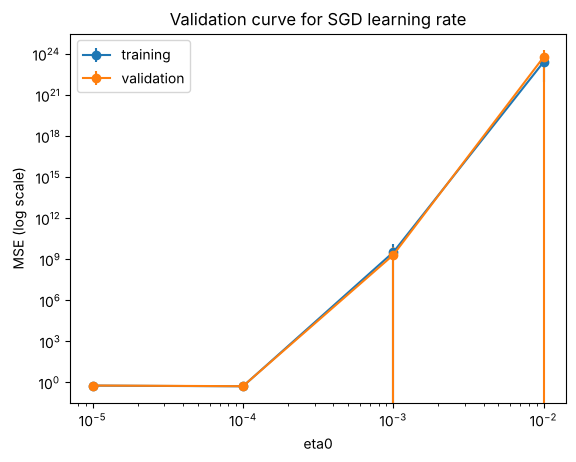

,train MSE,valid MSE,valid std
0.00001,5.880000e-01,5.980000e-01,2.400000e-02
0.00010,5.230000e-01,5.330000e-01,2.300000e-02
0.00100,3.230610e+09,2.053198e+09,6.159397e+09
0.01000,2.542762e+23,5.787933e+23,1.262395e+24


In [10]:
plt.errorbar(eta0_values, train_err.mean(axis=1), yerr=train_err.std(axis=1), marker='o', label='training')
plt.errorbar(eta0_values, valid_err.mean(axis=1), yerr=valid_err.std(axis=1), marker='o', label='validation')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('eta0'); plt.ylabel('MSE (log scale)')
plt.title('Validation curve for SGD learning rate')
plt.legend()
plt.show()

pd.DataFrame({'train MSE': train_err.mean(axis=1), 'valid MSE': valid_err.mean(axis=1),
              'valid std': valid_err.std(axis=1)}, index=eta0_values).round(3)

Same picture with cross validation: 1e-4 gives the lowest validation error. At 1e-3 and above the
average error is in the billions, because on some splits training blew up completely (the error axis
needs a log scale). 1e-5 is fine but hasn't quite converged in the default number of epochs.

(The y-axis label in the course version said MAE in k$, but the scoring was MSE and the target is in
$100k.)

## 5. Schedules, early stopping and averaging

Settings used below:

* `learning_rate` - how the step size changes over time:
  * `'constant'`: always `eta0`
  * `'invscaling'` (default): `eta0 / t^power_t`, shrinks as training goes on
  * `'adaptive'`: stays at `eta0` while the loss keeps improving, divides by 5 when it stalls
* `early_stopping=True` - holds out `validation_fraction` of the training data and stops when the score on
  it hasn't improved by `tol` for `n_iter_no_change` epochs
* `average=10` - after the first 10 updates, keeps a running average of the weights and uses that at the
  end, which smooths out the noise from individual SGD steps
* `max_iter` - a rule of thumb from the sklearn docs is about 10^6 / n_samples epochs (it must be an int)

In [11]:
max_iter = int(np.ceil(1e6 / com_train_features.shape[0]))
max_iter

65

In [12]:
results = []
warnings.simplefilter("ignore", ConvergenceWarning)    # invscaling hits max_iter, that's expected here
for schedule in ["invscaling", "constant", "adaptive"]:
    model = Pipeline([("scale", StandardScaler()),
                      ("sgd", SGDRegressor(max_iter=max_iter, early_stopping=True, eta0=1e-4, tol=1e-3,
                                           learning_rate=schedule, validation_fraction=0.2,
                                           n_iter_no_change=5, average=10, random_state=42))])
    model.fit(train_features, train_labels)
    results.append({
        'learning_rate': schedule,
        'epochs': model[-1].n_iter_,
        'weight updates': int(model[-1].t_),
        'train MAE': mean_absolute_error(train_labels, model.predict(train_features)),
        'dev MAE': mean_absolute_error(dev_labels, model.predict(dev_features)),
    })

pd.DataFrame(results).set_index('learning_rate').round(4)

,epochs,weight updates,train MAE,dev MAE
learning_rate,,,,
invscaling,65,754651,0.6845,0.6754
constant,28,325081,0.5379,0.5257
adaptive,43,499231,0.5339,0.5222


With `eta0=1e-4`:

* `invscaling` shrinks an already small step size, so it runs out of epochs (65) before it gets there.
* `constant` gets to about the same error as `LinearRegression` in under 30 epochs.
* `adaptive` ends up in the same place, taking a few more epochs because it keeps reducing the step size
  and trying again before giving up.

With `eta0=1e-3` instead, `invscaling` is the one that works, since its shrinking step size calms things
down after a few epochs, while `constant` and `adaptive` can blow up depending on the data. That's the
general lesson: the schedule and `eta0` have to be tuned together.

`n_iter_` is the number of epochs run. `t_` is the number of individual weight updates, roughly epochs x
number of training samples (minus the 20% held out for early stopping).

## Final check

In [13]:
final = Pipeline([("scale", StandardScaler()),
                  ("sgd", SGDRegressor(max_iter=max_iter, early_stopping=True, eta0=1e-4, tol=1e-3,
                                       learning_rate="constant", validation_fraction=0.2,
                                       n_iter_no_change=5, average=10, random_state=42))])
final.fit(com_train_features, com_train_labels)

ols = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())]).fit(com_train_features, com_train_labels)

print(f"SGD test MAE:              {mean_absolute_error(test_labels, final.predict(test_features)):.3f}")
print(f"LinearRegression test MAE: {mean_absolute_error(test_labels, ols.predict(test_features)):.3f}")

SGD test MAE:              0.533
LinearRegression test MAE: 0.530


In [14]:
pd.DataFrame({'SGD': final[-1].coef_, 'LinearRegression': ols[-1].coef_}, index=features.columns).round(3)

,SGD,LinearRegression
MedInc,0.793,0.852
HouseAge,0.157,0.121
AveRooms,-0.150,-0.302
AveBedrms,0.181,0.349
Population,0.008,-0.002
AveOccup,-0.044,-0.041
Latitude,-0.516,-0.893
Longitude,-0.483,-0.868


The test error is practically the same, but the coefficients aren't: Latitude and Longitude are much
smaller in the SGD model. They're strongly correlated with each other (-0.92), so there's a long, flat valley
of weight combinations that all give nearly the same predictions. SGD stops as soon as improvements get
small, which leaves it somewhere in that valley, and the default `penalty='l2'` pulls the weights towards
zero a bit as well. Same predictions, different explanation, which is worth remembering before reading
too much into individual coefficients.

## Summary

* SGD needs **scaled features**, otherwise it diverges
* plot the training loss per epoch to spot a learning rate that's too big (noisy/increasing) or too small (slow)
* `validation_curve` for choosing `eta0` properly
* `early_stopping`, `average` and a sensible `max_iter` make it converge quickly and reliably
* for a dataset this size `LinearRegression` is simpler and exact. SGD is worth it for much bigger data,
  streaming data (`partial_fit`), or when combined with penalties (see the next notebook)